# 12Go Travel Data Analysis - EPS Investigation

**Objective:** Investigate EPS (Earn Per Seat) changes between 2019 and 2023

**Key Metrics:**
- EPS = System Fee (USD) / Number of Seats
- Comparing Q1-Q3 2019 vs Q1-Q3 2023

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [2]:
# Load environment variables and create database connection
load_dotenv()
DATABASE_URL = os.getenv('DATABASE_URL')

# Fix: Database is MySQL/MariaDB, not PostgreSQL
if DATABASE_URL.startswith('postgresql://'):
    DATABASE_URL = DATABASE_URL.replace('postgresql://', 'mysql+pymysql://')
    print("Note: Converted PostgreSQL URL to MySQL")

# Create engine
engine = create_engine(DATABASE_URL)

# Test connection
with engine.connect() as conn:
    result = conn.execute(text("SELECT DATABASE(), @@version"))
    db_info = result.fetchone()
    print(f"✓ Connected to database: {db_info[0]}")
    print(f"✓ MySQL/MariaDB version: {db_info[1][:50]}...")

Note: Converted PostgreSQL URL to MySQL


✓ Connected to database: 12go
✓ MySQL/MariaDB version: 10.3.11-MariaDB-1:10.3.11+maria~bionic...


## 1. Data Exploration - Understanding the Schema

In [3]:
# Get table structure
query_columns = """
SELECT column_name, data_type, is_nullable
FROM information_schema.columns
WHERE table_name = 'analytic_test_booking'
ORDER BY ordinal_position;
"""

columns_info = pd.read_sql(query_columns, engine)
print(f"Total columns: {len(columns_info)}")
print("\nKey columns:")
display(columns_info.head(15))

Total columns: 43

Key columns:


,column_name,data_type,is_nullable
0,bid,int,NO
1,paidon,datetime,YES
2,paygate_code,varchar,YES
3,status_id,varchar,YES
4,seller_id,int,NO
5,operator_id,int,YES
6,class_id,int,YES
7,class_name,varchar,YES
8,from_id,int,YES
9,from_province_id,int,YES


In [4]:
# Get sample data
query_sample = "SELECT * FROM analytic_test_booking LIMIT 3"
sample_data = pd.read_sql(query_sample, engine)

print("Sample record (transposed):")
display(sample_data.iloc[0].to_frame())

Sample record (transposed):


,0
bid,4330354
paidon,2019-01-01 00:03:14
paygate_code,omise3ds
status_id,CONFIRMED
seller_id,2094
operator_id,203
class_id,6
class_name,Express
from_id,8850
from_province_id,1


## 2. Overall EPS Analysis

In [5]:
# Calculate EPS for 2019 vs 2023
query_eps = """
SELECT
    YEAR(createdon_date) as year,
    COUNT(*) as total_bookings,
    SUM(seats) as total_seats,
    SUM(sysfee_usd) as total_sysfee,
    SUM(agfee_usd) as total_agfee,
    SUM(netprice_usd) as total_netprice,
    SUM(total_usd) as total_revenue,
    ROUND(SUM(sysfee_usd) / SUM(seats), 2) as eps,
    ROUND(AVG(sysfee_usd), 2) as avg_sysfee_per_booking,
    COUNT(CASE WHEN refund_date IS NOT NULL THEN 1 END) as refunded_bookings,
    ROUND(COUNT(CASE WHEN refund_date IS NOT NULL THEN 1 END) * 100.0 / COUNT(*), 2) as refund_rate_pct
FROM analytic_test_booking
WHERE YEAR(createdon_date) IN (2019, 2023)
    AND MONTH(createdon_date) BETWEEN 1 AND 9
GROUP BY YEAR(createdon_date)
ORDER BY year;
"""

eps_data = pd.read_sql(query_eps, engine)
print("EPS Comparison - Q1-Q3:")
display(eps_data)

if len(eps_data) == 2:
    eps_change = eps_data.iloc[1]['eps'] - eps_data.iloc[0]['eps']
    eps_pct_change = (eps_change / eps_data.iloc[0]['eps']) * 100
    print(f"\n📊 EPS Change: ${eps_change:.2f} ({eps_pct_change:+.2f}%)")
    print(f"📊 Booking Volume Change: {eps_data.iloc[1]['total_bookings'] - eps_data.iloc[0]['total_bookings']:+,}")
    print(f"📊 Refund Rate Change: {eps_data.iloc[1]['refund_rate_pct'] - eps_data.iloc[0]['refund_rate_pct']:+.2f}%")

EPS Comparison - Q1-Q3:


,year,total_bookings,total_seats,total_sysfee,total_agfee,total_netprice,total_revenue,eps,avg_sysfee_per_booking,refunded_bookings,refund_rate_pct
0,2019,611850,1223582.0,2.062481e+06,1.059630e+06,1.466952e+07,3.470678e+07,1.69,3.37,47047,7.69
1,2023,2235666,4124310.0,7.264046e+06,7.370093e+05,4.606775e+07,9.453192e+07,1.76,3.25,77963,3.49



📊 EPS Change: $0.07 (+4.14%)
📊 Booking Volume Change: +1,623,816.0
📊 Refund Rate Change: -4.20%


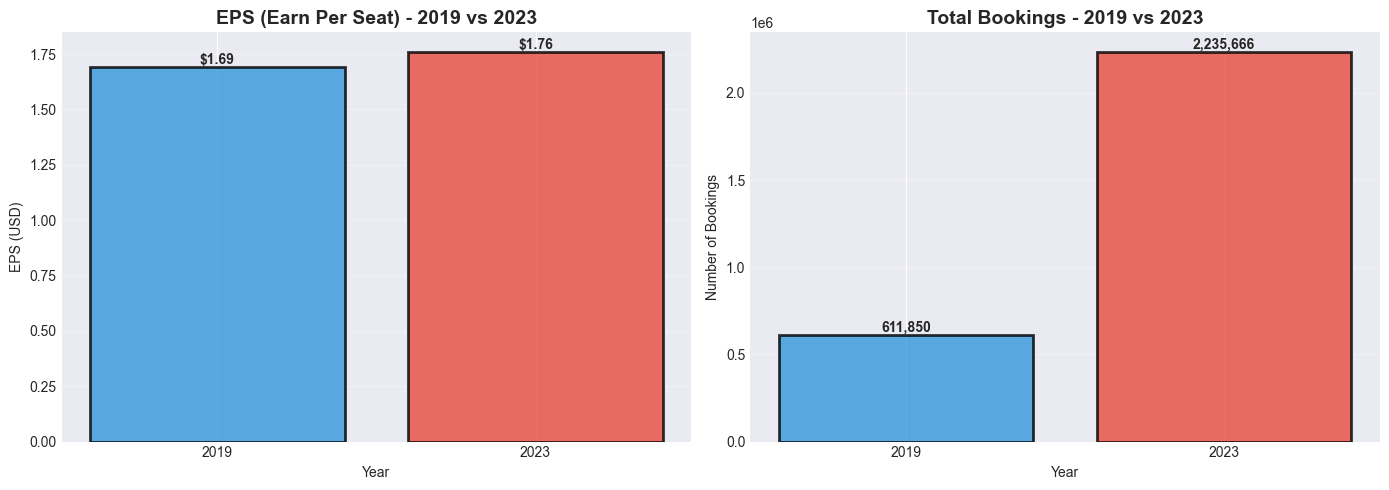

In [6]:
# Visualize EPS comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: EPS Comparison
colors = ['#3498db', '#e74c3c']
axes[0].bar(eps_data['year'].astype(str), eps_data['eps'], color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[0].set_title('EPS (Earn Per Seat) - 2019 vs 2023', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('EPS (USD)')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(eps_data['eps']):
    axes[0].text(i, v, f'${v:.2f}', ha='center', va='bottom', fontweight='bold')

# Chart 2: Total Bookings
axes[1].bar(eps_data['year'].astype(str), eps_data['total_bookings'], color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_title('Total Bookings - 2019 vs 2023', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Bookings')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(eps_data['total_bookings']):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Monthly Trends Analysis

Monthly EPS Trends:


,year,month,bookings,seats,eps,avg_booking_value
0,2019,1,82217,160376.0,1.76,55.49
1,2019,2,72276,139903.0,1.70,54.02
2,2019,3,75214,146611.0,1.70,54.30
3,2019,4,63621,125486.0,1.60,53.64
4,2019,5,56000,114291.0,1.60,55.95
5,2019,6,55621,115194.0,1.63,60.26
6,2019,7,78079,166398.0,1.53,60.78
7,2019,8,72170,145709.0,1.73,58.66
8,2019,9,56652,109614.0,1.96,57.89
9,2023,1,253575,462948.0,1.82,42.70


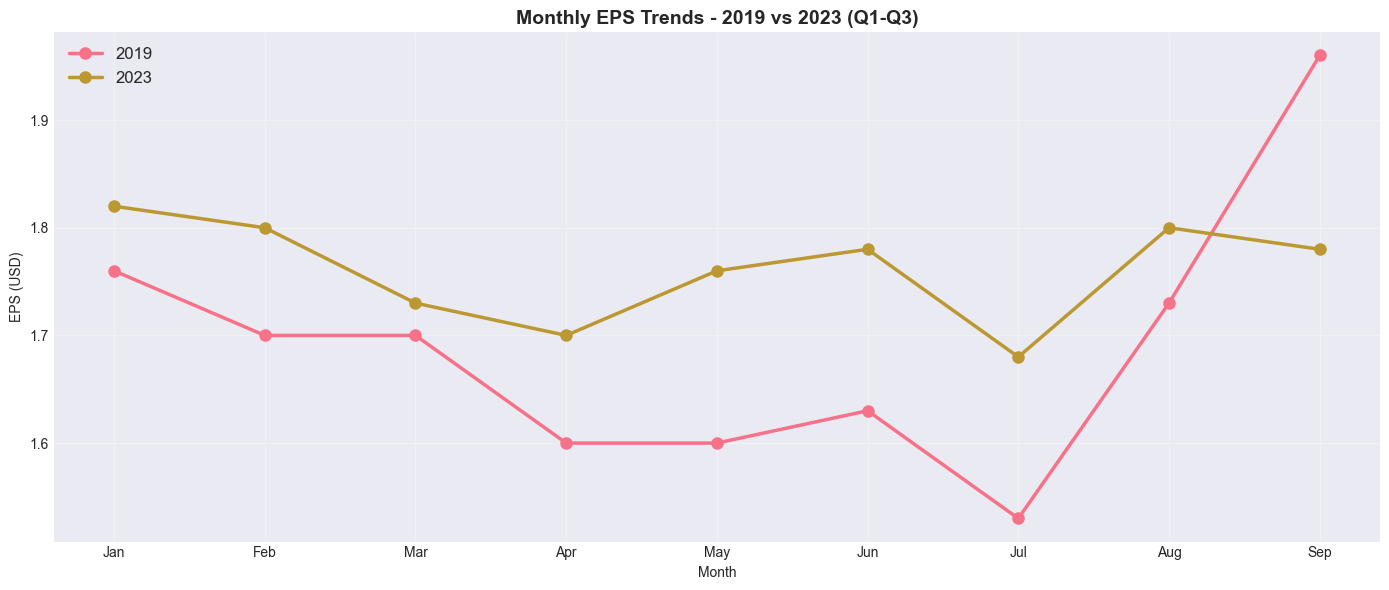

In [7]:
# Monthly EPS trends
query_monthly = """
SELECT
    YEAR(createdon_date) as year,
    MONTH(createdon_date) as month,
    COUNT(*) as bookings,
    SUM(seats) as seats,
    ROUND(SUM(sysfee_usd) / SUM(seats), 2) as eps,
    ROUND(AVG(total_usd), 2) as avg_booking_value
FROM analytic_test_booking
WHERE YEAR(createdon_date) IN (2019, 2023)
    AND MONTH(createdon_date) BETWEEN 1 AND 9
GROUP BY YEAR(createdon_date), MONTH(createdon_date)
ORDER BY year, month;
"""

monthly_trends = pd.read_sql(query_monthly, engine)
print("Monthly EPS Trends:")
display(monthly_trends)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))

for year in [2019, 2023]:
    data = monthly_trends[monthly_trends['year'] == year]
    ax.plot(data['month'], data['eps'], marker='o', linewidth=2.5, label=f'{year}', markersize=8)

ax.set_title('Monthly EPS Trends - 2019 vs 2023 (Q1-Q3)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('EPS (USD)')
ax.set_xticks(range(1, 10))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'])
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Vehicle Class Analysis

In [8]:
# EPS by vehicle class
query_vehicle = """
SELECT
    YEAR(createdon_date) as year,
    vehclass_id as vehicle_class,
    COUNT(*) as bookings,
    SUM(seats) as seats,
    ROUND(SUM(sysfee_usd) / SUM(seats), 2) as eps,
    ROUND(SUM(total_usd), 2) as total_revenue
FROM analytic_test_booking
WHERE YEAR(createdon_date) IN (2019, 2023)
    AND MONTH(createdon_date) BETWEEN 1 AND 9
    AND vehclass_id IS NOT NULL
GROUP BY YEAR(createdon_date), vehclass_id
ORDER BY year, eps DESC;
"""

vehicle_analysis = pd.read_sql(query_vehicle, engine)

# Calculate market share percentages
for year in [2019, 2023]:
    year_data = vehicle_analysis[vehicle_analysis['year'] == year]
    total = year_data['bookings'].sum()
    vehicle_analysis.loc[vehicle_analysis['year'] == year, 'market_share_pct'] = (
        year_data['bookings'] / total * 100
    )

print("EPS by Vehicle Class:")
display(vehicle_analysis.round(2))

EPS by Vehicle Class:


,year,vehicle_class,bookings,seats,eps,total_revenue,market_share_pct
0,2019,railpass,43,58.0,8.24,24888.90,0.01
1,2019,charter,9495,9495.0,6.15,944550.04,1.55
2,2019,daytrip,151,204.0,4.27,7697.35,0.02
3,2019,train,94395,205795.0,3.80,8011796.60,15.43
4,2019,avia,58019,114796.0,2.20,9050263.04,9.48
5,2019,carrent,48,129.0,2.11,19493.70,0.01
6,2019,ferry,133403,288507.0,1.32,7326073.44,21.80
7,2019,bus,216708,405323.0,1.09,7817091.90,35.42
8,2019,van,45164,90253.0,0.84,1186163.37,7.38
9,2019,insurance,54424,109022.0,0.61,318759.66,8.89


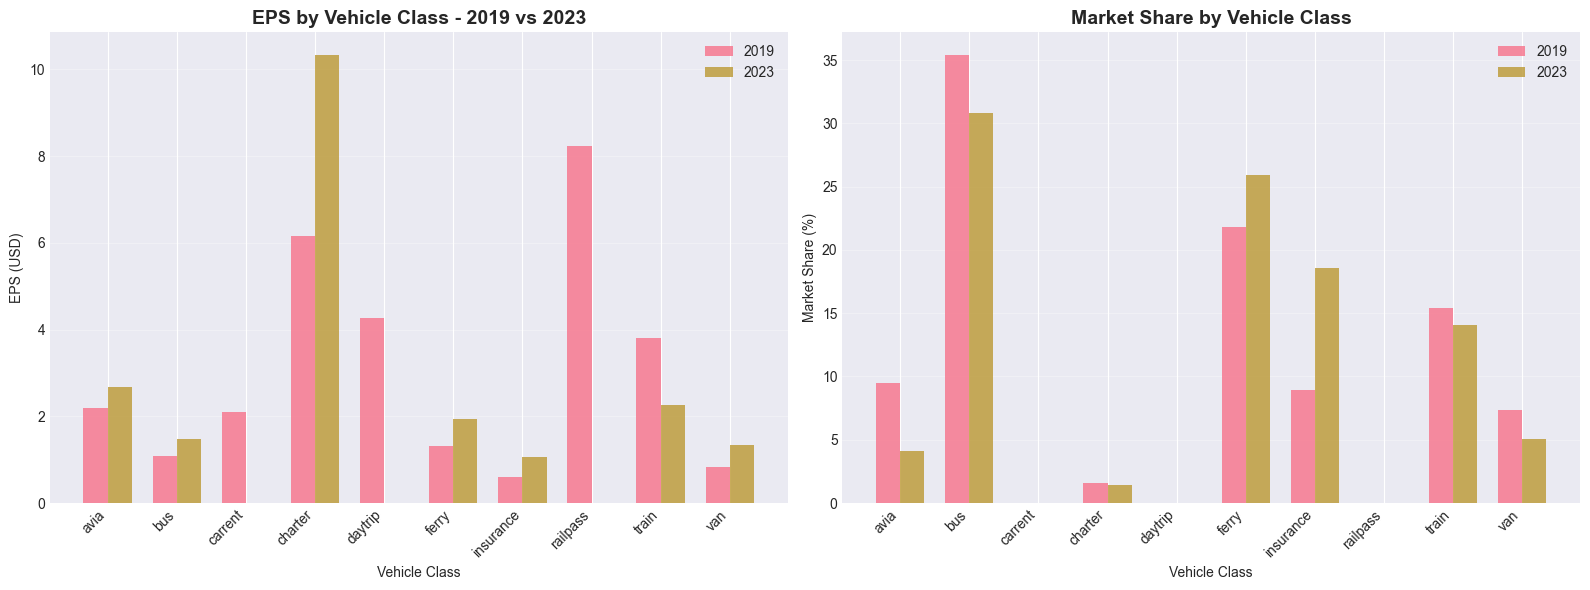

In [9]:
# Visualize vehicle class comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vehicle_classes = sorted(vehicle_analysis['vehicle_class'].unique())
x = np.arange(len(vehicle_classes))
width = 0.35

# Chart 1: EPS by vehicle class
for i, year in enumerate([2019, 2023]):
    data = vehicle_analysis[vehicle_analysis['year'] == year]
    eps_values = [data[data['vehicle_class'] == vc]['eps'].values[0] if len(data[data['vehicle_class'] == vc]) > 0 else 0
                  for vc in vehicle_classes]
    axes[0].bar(x + i*width, eps_values, width, label=str(year), alpha=0.8)

axes[0].set_title('EPS by Vehicle Class - 2019 vs 2023', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Vehicle Class')
axes[0].set_ylabel('EPS (USD)')
axes[0].set_xticks(x + width/2)
axes[0].set_xticklabels(vehicle_classes, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Chart 2: Market share
for i, year in enumerate([2019, 2023]):
    data = vehicle_analysis[vehicle_analysis['year'] == year]
    mkt_share = [data[data['vehicle_class'] == vc]['market_share_pct'].values[0] if len(data[data['vehicle_class'] == vc]) > 0 else 0
                 for vc in vehicle_classes]
    axes[1].bar(x + i*width, mkt_share, width, label=str(year), alpha=0.8)

axes[1].set_title('Market Share by Vehicle Class', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Vehicle Class')
axes[1].set_ylabel('Market Share (%)')
axes[1].set_xticks(x + width/2)
axes[1].set_xticklabels(vehicle_classes, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Geographic Analysis

In [10]:
# Top customer origin countries
query_countries = """
SELECT
    YEAR(createdon_date) as year,
    user_origin_country_id as country,
    COUNT(*) as bookings,
    ROUND(SUM(sysfee_usd) / SUM(seats), 2) as eps
FROM analytic_test_booking
WHERE YEAR(createdon_date) IN (2019, 2023)
    AND MONTH(createdon_date) BETWEEN 1 AND 9
    AND user_origin_country_id IS NOT NULL
GROUP BY YEAR(createdon_date), user_origin_country_id
HAVING bookings > 1000
ORDER BY year, bookings DESC
LIMIT 30;
"""

country_data = pd.read_sql(query_countries, engine)
print("Top Customer Origin Countries:")
display(country_data.head(20))

Top Customer Origin Countries:


,year,country,bookings,eps
0,2019,TH,210363,1.58
1,2019,VN,41763,1.42
2,2019,PH,41406,1.15
3,2019,FR,28072,1.67
4,2019,GB,26753,2.34
5,2019,US,26055,2.26
6,2019,DE,25713,2.08
7,2019,MY,23768,0.84
8,2019,NL,18073,2.05
9,2019,ES,17481,1.63


## 6. Summary Statistics

In [11]:
# Generate summary
print("="*80)
print(" " * 25 + "EPS ANALYSIS SUMMARY")
print("="*80)
print()
print("PERIOD: Q1-Q3 2019 vs Q1-Q3 2023")
print()
print("KEY FINDINGS:")
print("-" * 80)

if len(eps_data) == 2:
    for _, row in eps_data.iterrows():
        print(f"\n{int(row['year'])}:")
        print(f"  Total Bookings: {row['total_bookings']:,}")
        print(f"  Total Seats: {row['total_seats']:,.0f}")
        print(f"  Total Revenue: ${row['total_revenue']:,.2f}")
        print(f"  EPS: ${row['eps']:.2f}")
        print(f"  Refund Rate: {row['refund_rate_pct']:.2f}%")

    eps_delta = eps_data.iloc[1]['eps'] - eps_data.iloc[0]['eps']
    eps_pct = (eps_delta / eps_data.iloc[0]['eps']) * 100
    
    print("\n" + "="*80)
    print(f"\n🎯 EPS CHANGE: ${eps_delta:.2f} ({eps_pct:+.2f}%)")
    
    if eps_pct > 0:
        print("\n✅ POSITIVE FINDING: EPS INCREASED despite massive growth!")
    else:
        print("\n⚠️ ATTENTION: EPS DECREASED - Investigation needed")
    
    booking_growth = ((eps_data.iloc[1]['total_bookings'] - eps_data.iloc[0]['total_bookings']) / 
                     eps_data.iloc[0]['total_bookings'] * 100)
    print(f"📈 BOOKING GROWTH: +{booking_growth:.1f}%")
    
    refund_change = eps_data.iloc[1]['refund_rate_pct'] - eps_data.iloc[0]['refund_rate_pct']
    print(f"{'✅' if refund_change < 0 else '⚠️'} REFUND RATE CHANGE: {refund_change:+.2f}%")

print("\n" + "="*80)
print("\nAnalysis complete! Check README.md for full presentation.")
print("Charts available in /charts directory")

                         EPS ANALYSIS SUMMARY

PERIOD: Q1-Q3 2019 vs Q1-Q3 2023

KEY FINDINGS:
--------------------------------------------------------------------------------

2019:
  Total Bookings: 611,850.0
  Total Seats: 1,223,582
  Total Revenue: $34,706,778.00
  EPS: $1.69
  Refund Rate: 7.69%

2023:
  Total Bookings: 2,235,666.0
  Total Seats: 4,124,310
  Total Revenue: $94,531,918.49
  EPS: $1.76
  Refund Rate: 3.49%


🎯 EPS CHANGE: $0.07 (+4.14%)

✅ POSITIVE FINDING: EPS INCREASED despite massive growth!
📈 BOOKING GROWTH: +265.4%
✅ REFUND RATE CHANGE: -4.20%


Analysis complete! Check README.md for full presentation.
Charts available in /charts directory


In [12]:
# Close connection
engine.dispose()
print("\n✓ Database connection closed")


✓ Database connection closed
